# Dados de Entrada
* Selecione "Adicionar ao Drive"
* Links:
  * https://tinyurl.com/bigdata-gut-pt
  * https://tinyurl.com/bd-votos



  




## Acesso ao Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls '/content/drive/My Drive/gut-pt'

all  small


# Setup

## Instalação de pacotes

In [3]:
!pip install pyspark

## Preparação do ambiente

In [ ]:
from pyspark.sql import SparkSession

appName = 'Big Data'
master = 'local[*]'

spark = SparkSession.builder     \
    .master(master) \
    .appName(appName) \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

## Criação de RDD

In [ ]:
data = [1, 2, 3, 4, 5]
distributed_data = spark.sparkContext.parallelize(data)

In [ ]:
data

In [ ]:
distributed_data

In [ ]:
distributed_data.getNumPartitions()

# Exemplo Básico: contagem de palavras

## Leitura dos dados e operações com RDD

In [ ]:
input_data = spark.sparkContext.textFile('/content/drive/My Drive/gut-pt/small/*')


In [ ]:
input_data

In [ ]:
few_lines = input_data.take(10)


In [ ]:
print(few_lines)


In [ ]:
print(few_lines)
for l in few_lines :
  print(l)

In [ ]:
# Cuidado! Pode ser muito grande!
#all_lines = input_data.collect()
#for l in all_lines :
#  print(l)

cnt = input_data.count()

print("Total de linhas:",cnt)

In [ ]:
input_data.getNumPartitions()

In [ ]:
!ls "/content/drive/My Drive/gut-pt/small/"*

## Separação de palavras (map)

In [ ]:
input_data.take(10)

In [ ]:
input_data.count()

In [ ]:
'The Project Gutenberg EBook of Noites de insomnia, offerecidas a quem não'.split()

In [ ]:
# Modifique o template para processar as palavras de cada linha
def process_line(line) :
  yield (None, None)



In [ ]:
input_data.take(10)

In [ ]:
words = input_data.flatMap(process_line);

In [ ]:
words

In [ ]:
# Comportamento do map

#for line in input_data :
#  process_line(line)

In [ ]:
words.take(100)

In [ ]:
words.count()

In [ ]:
words.getNumPartitions()

**Pare aqui!**

Implemente a sua solução antes de continuar

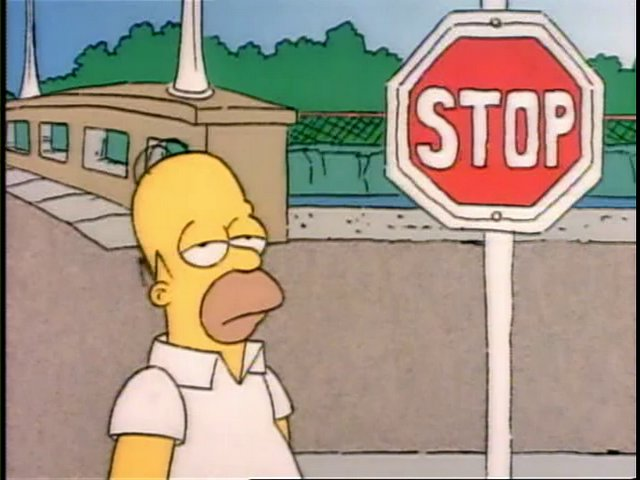

## Separação de palavras (versão inicial)

In [ ]:
# Modifique o template para processar as palavras de cada linha
def process_line(line) :
  words = line.split()
  for word in words :
    yield (word, 1)

In [ ]:
words = input_data.flatMap(process_line);

In [ ]:
words.take(100)

## Separação de palavras (pontuação, ineficiente)

In [ ]:
def process_line(line) :
  line = line.lower()
  for char in '`~º!@#$%^&*()_-+=/*-,./<>?;:\'\"[]{}|0123456789\'\"' :
    line = line.replace(char, ' ')
  words = line.split()
  for word in words :
    yield (word, 1)

In [ ]:
words = input_data.flatMap(process_line);

In [ ]:
words.take(100)

In [ ]:
words.count()

## Separação de palavras (expressão regular)

In [ ]:
import re

def process_line(line) :
  line = re.sub('[^a-záàâãéêíóôõúç ]', ' ', line.lower())
  words = line.split()
  for word in words :
    yield (word, 1)

In [ ]:
words = input_data.flatMap(process_line);

In [ ]:
# Comportamento

#for line in input_data :
#  process_line(line)

In [ ]:
words.take(10)

In [ ]:
words.count()

In [ ]:
words.getNumPartitions()

## Contagem (Reduce)

In [ ]:
def accumulate(acc, v) :
  return acc + v

In [ ]:
# Comportamento interno
#output = []
#for k in keys:
#    values = values_for(k)
#    acc = values[0]
#    for v in values[1:]:
#        acc = f(acc, v)
#    output.append((k, acc))



In [ ]:
# chave: exemplo
# valores [1 1 1 1] -> [4]
#         [1 1 1] -> [3]
#         [1 1 1 1 1] -> [5]
#         [1 1 1 1 1 1 1] -> [6]
#         [1 1 ] -> [2]
#         -> [20]

# [1 1 1 1] [1 1 1]. [1 1 1 1 1]. [1 1]
# [2 1 1].  [2 1].   [2 1 1 1].   [2]
# [3 1].    [3].     [3 1 1]
# [4]                [4 1]
#.                   [5]

In [ ]:
wc = words.reduceByKey(accumulate)

In [ ]:
wc.take(100)

In [ ]:
wc.collect()

In [ ]:
wc.count()

In [ ]:
wc.getNumPartitions()

In [ ]:
## Entradas: linhas de texto
## ['uma linha de texto', 'outra linha de texto']
## map processa um elemento da entrada, gera par (chave, valor)
## -> (uma, 1) (linha, 1) (de, 1), ... (linha, 1), ...
## reduce agrupa valores para cada chave diferente, aplica função de redução (no ex: soma)
## -> chave: linha, valores: 1, 1 -> 1+1 -> 2

## Contagem usando funções lambda

In [ ]:
input_data.take(10)

In [ ]:
clean_lines = input_data.map(lambda line: re.sub('[^a-zà-ù ]', ' ', line.lower()))

In [ ]:
clean_lines.take(10)

In [ ]:
words = clean_lines.flatMap(lambda line: line.split())

In [ ]:
words.take(10)

In [ ]:
counts = words.map(lambda word: (word, 1))

In [ ]:
counts.take(10)

In [ ]:
wc = counts.reduceByKey(lambda acc, v: acc + v)

In [ ]:
wc.take(10)

In [ ]:
wc = input_data.map(lambda line: re.sub('[^a-zà-ù ]', ' ', line.lower()))  \
    .flatMap(lambda line: line.split())  \
    .map(lambda word: (word, 1)) \
    .reduceByKey(lambda acc, v: acc + v)

In [ ]:
wc.take(10)

# Exercício: Apuração Eleitoral

Dados: https://tinyurl.com/bd-votos

In [ ]:
entrada_eleicao =  spark.sparkContext.textFile('/content/drive/My Drive/boletim_urna/bweb_sample.csv')

In [ ]:
!ls '/content/drive/My Drive/boletim_urna/bweb_sample.csv'

In [ ]:
entrada_eleicao.take(10)

In [ ]:
def separa_campos(linha) :
  campos = linha.split(';')
  yield (None, 0)

In [ ]:
votos = entrada_eleicao.flatMap(separa_campos)

In [ ]:
votos.take(10)

In [ ]:
# Função Reduce
totais = votos.reduceByKey(lambda acc,v : acc+v)

In [ ]:
totais.collect()

**Pare aqui!**

Implemente a sua solução antes de continuar

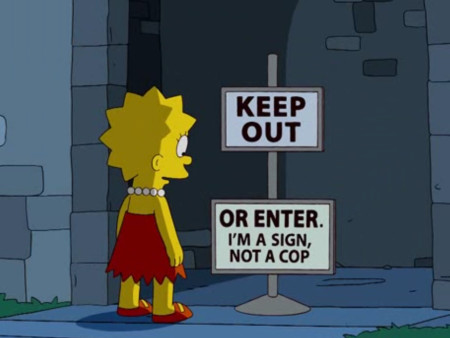

In [ ]:
# Amostra de dados (~1%)
entrada_eleicao =  spark.sparkContext.textFile('/content/drive/My Drive/boletim_urna/bweb_sample.csv')

In [ ]:
entrada_eleicao.take(10)

In [ ]:
def limpa_linha(line) :
  return line.replace('\"','')

In [ ]:
eleicao_limpa = entrada_eleicao.map(limpa_linha)

In [ ]:
eleicao_limpa.take(10)

In [ ]:
def separa_campos(line) :
  return(line.split(';'))

In [ ]:
campos_eleicao = eleicao_limpa.map(separa_campos)

In [ ]:
campos_eleicao.take(10)

In [ ]:
campos_eleicao.getNumPartitions()

In [ ]:
def filtra_governador(campos) :
  if(campos[17] == 'Governador') :
    return campos

In [ ]:
campos_filtrados = campos_eleicao.filter(filtra_governador)

In [ ]:
campos_filtrados.count()

In [ ]:
campos_filtrados.take(10)

In [ ]:
def nome_votos(campos) :
  return([campos[30], int(campos[31])])

In [ ]:
parciais = campos_filtrados.map(nome_votos)

In [ ]:
parciais.take(10)

In [ ]:
totais = parciais.reduceByKey(lambda acc,v: acc+v)

In [ ]:
totais.collect()

In [ ]:
entrada_eleicao =  spark.sparkContext.textFile('/content/drive/My Drive/boletim_urna/bweb_1t_SP_051020221321.utf8.csv.bz2')

In [ ]:
entrada_eleicao.take(10)

In [ ]:
res_map = entrada_eleicao.map(lambda line: line.replace('\"','').split(';')) \
  .filter(lambda campos: campos[17] == 'Governador') \
  .map(lambda campos: [campos[30], int(campos[31])]) \
  .reduceByKey(lambda acc,v: acc+v)

In [ ]:
res_map.collect()

#Exemplo da aula: Contagem de amigos em Comum

In [ ]:
%%file friends.txt
André:Carlos,Diana,Edson,Zélia
Bia:Carlos,Edson,Zélia
Carlos:André,Bia,Diana
Diana:André,Carlos,Zélia
Edson:André,Bia,Zélia
Zélia:André,Bia,Diana,Edson


In [ ]:
def list_of_friends(line):
    person, friends_str = line.strip().split(":")
    friends = friends_str.split(",")

    for friend in friends:
        pair = sorted([person, friend])
        yield (tuple(pair), set(friends))

In [ ]:
friends_data = spark.sparkContext.textFile("friends.txt")

# Apply the mapper
mapped = friends_data.flatMap(list_of_friends)

In [ ]:
mapped.take(10)

In [ ]:
common_friends = mapped.reduceByKey(
    lambda friends1, friends2: friends1.intersection(friends2)
)

# Só depois convertemos o conjunto em uma contagem
reduced = common_friends.mapValues(len)



In [ ]:
reduced.collect()